In [122]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from blackjax.util import run_inference_algorithm
from sklearn.preprocessing import StandardScaler

from non_parametric_pro import ula
from non_parametric_pro.density import ProParameters, pro_logdensity_fn, pro_score_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, train_val_split
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation
from non_parametric_pro.inducing import PointInducingBasis, compute_inducing_basis, kmeans_inducing_points
from non_parametric_pro.gp import _full_gp_basis, predictive_log_likelihood

jax.config.update("jax_enable_x64", True)

In [11]:
dataset_name = "airfoil"
split = 1

num_inducing_points = 200
val_fraction = 0.2

num_particles = 50

In [18]:
key = jr.PRNGKey(0)

example = load_uci_regression_dataset(dataset_name, split=split)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_full = scaler_x.fit_transform(example.x_train)
y_full = scaler_y.fit_transform(example.y_train)

data_split = train_val_split(key, x_full, y_full, val_fraction=val_fraction)
x_train, y_train, x_val, y_val = data_split.x_train, data_split.y_train, data_split.x_val, data_split.y_val

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [19]:
M = num_inducing_points
D = x_full.shape[1]
N = x_full.shape[0]

data = gpx.Dataset(X=x_full, y=y_full)
kernel = gpx.kernels.Matern32(lengthscale=jnp.ones((D,)), variance=px.NonTrainable(jnp.array(1.0)))
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood
optim = ox.adam(learning_rate=0.01)

z_init = kmeans_inducing_points(key, x_full, M).z 

variational_family = gpx.variational_families.CollapsedVariationalGaussian(
    posterior=posterior,
    inducing_inputs=z_init,
)

opt_variational_family, _ = gpx.fit(
    model=variational_family,
    objective=lambda p, d: -gpx.objectives.collapsed_elbo(p, d),
    train_data=data,
    optim=optim,
    num_iters=500,
    verbose=False,
)

v_gp_posterior = opt_variational_family.posterior

v_gp_latent_dist = v_gp_posterior.predict(x_test, train_data=data)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

v_gp_sigma = v_gp_posterior.likelihood.obs_stddev
v_gp_kernel = v_gp_posterior.prior.kernel

z_opt = px.unwrap(opt_variational_family.inducing_inputs)

print("VGP NLPD:", nlpd_gp(y_test, v_gp_predictive_mean, v_gp_predictive_std))

VGP NLPD: 0.0720942965094952


In [ ]:
# M = 100

# from non_parametric_pro.inducing import RFFInducingBasis, sample_rff_frequencies

# freqs = sample_rff_frequencies(key, v_gp_kernel, num_basis_fns=M)
# rff_basis = RFFInducingBasis(frequencies=freqs)
# basis, residual_std = compute_inducing_basis(rff_basis, kernel, x_train)

# inducing_basis = RFFInducingBasis(frequencies=freqs)



In [97]:
from non_parametric_pro.density import ProParameters, pro_logdensity_fn

Running parameter adaptation


<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

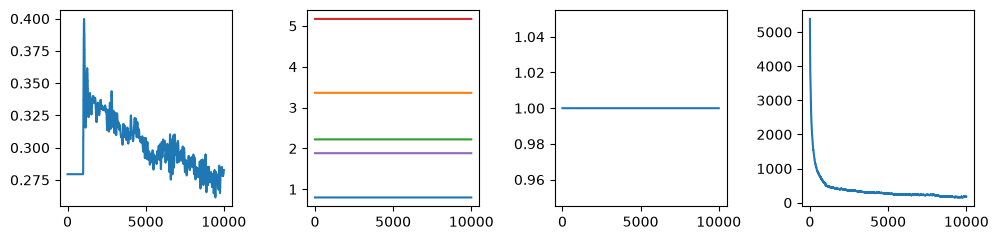

In [121]:
x = x_train
y = y_train
_x_val = x_val
_y_val = y_val

inducing_basis = PointInducingBasis(z=z_opt)
basis, residual_std = compute_inducing_basis(inducing_basis, kernel, x)

num_particles = 1
J = num_particles

pro_kernel = v_gp_kernel

_sigma_val = px.unwrap(v_gp_sigma)
_sigma_min = 0.01

sigma = gpx.parameters.SigmoidBounded(_sigma_val, low=_sigma_min, high=100.0)

pro_params = ProParameters(
    y=y,
    basis=basis,
    step_size=1e-4,
    sigma=sigma,
    alpha=1,
    residual_std=residual_std
)

num_steps = 10000
warmup_steps = 1000
sigma_adapt_every = 10
kernel_adapt_every = -1
initial_position = jr.normal(key, (M, J))

adaptation = parameter_adaptation(
    ula,
    pro_logdensity_fn,
    pro_params,
    x_train=x,
    initial_kernel=pro_kernel,
    warmup_steps=warmup_steps,
    sigma_adapt_every=sigma_adapt_every,
    kernel_adapt_every=kernel_adapt_every,
    objective_fn=pro_logdensity_fn,
    inducing_basis=inducing_basis,
    sigma_optimizer=ox.adam(1e-1),
    kernel_optimizer=ox.adam(1e-1),
    x_val=_x_val,
    y_val=_y_val,
    progress_bar=True
)

adaptation_results, adaptation_info = adaptation.run(key, initial_position, num_steps=num_steps)
pro_kernel = jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
pro_params = adaptation_results.parameters
pro_position = adaptation_results.state.position

fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

ax[0].plot(px.unwrap(adaptation_info.sigma))
ax[1].plot(px.unwrap(adaptation_info.kernel.lengthscale))
ax[2].plot(px.unwrap(adaptation_info.kernel.variance))
ax[3].plot(-adaptation_info.sampler_info.score[10:])
plt.tight_layout()
plt.show()

In [118]:
import blackjax

mala = blackjax.mala(lambda z: pro_logdensity_fn(z, pro_params), 0.0002)
num_steps = 20000

out, info = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=mala,
    num_steps=num_steps,
    initial_position=adaptation_results.state.position,
    progress_bar=True
)

jnp.mean(info[1].acceptance_rate)

<div><progress max="20000" value="20000"></progress> 100.00% [20000/20000 00:00&lt;?]</div>

Array(0.81732338, dtype=float64)

In [105]:
# num_steps = 5000
# pro_params = pro_params._replace(step_size=1e-4)
# algorithm = parametric_ula(pro_logdensity_fn, pro_params)

# out, info = run_inference_algorithm(
#     rng_key=key,
#     inference_algorithm=algorithm,
#     num_steps=num_steps,
#     initial_position=pro_position,
#     progress_bar=True
# )

# plt.plot(-info[1].score)
# plt.show()

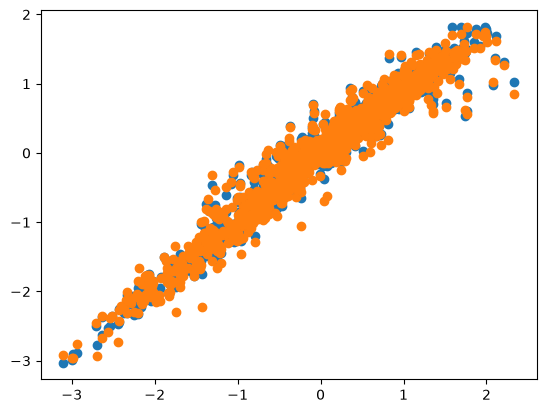

In [119]:
v_gp_latent_dist = v_gp_posterior.predict(x_train, train_data=data)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

burn = int(num_steps * 0.8)
thin = 50

particles = info[0].position[burn::thin]

test_basis, test_cov = prediction_basis(
    pro_kernel,
    x_train,
    x_train,
    pro_params,
    inducing_basis=inducing_basis,
)

particle_matrix = particles
if particles.ndim == 3:
    particle_matrix = jnp.transpose(particles, (1, 0, 2)).reshape(particles.shape[1], -1)

projected = test_basis @ particle_matrix      # (N_test, J_total)
mean = jnp.mean(projected, axis=1) 

plt.scatter(y_train, v_gp_predictive_mean)
plt.scatter(y_train, mean)
plt.show()

In [120]:
burn = int(num_steps * 0.8)
thin = 50

x = x_train
y = y_train
x_basis = x_train

particles = info[0].position[burn::thin]
test_basis, test_cov = prediction_basis(pro_kernel, x_basis, x, pro_params, inducing_basis=inducing_basis)

v_gp_latent_dist = v_gp_posterior.predict(x, train_data=data)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

print("PRO NLPD:", nlpd_pro(y, test_basis, test_cov, particles, parameters=pro_params))
print("VGP NLPD:", nlpd_gp(y, v_gp_predictive_mean, v_gp_predictive_std))

PRO NLPD: 0.0871955551411401
VGP NLPD: -0.0333617011363764


In [23]:
import paramax
from non_parametric_pro.util import _as_particle_matrix

def nlpd_pro(
    y_test: jax.Array,
    test_basis: jax.Array,
    test_covariance: jax.Array,
    particles: jax.Array,
    *,
    parameters: ProParameters,
    return_per_point: bool = False,
) -> jax.Array:
    """
    Mean negative log predictive density for the PRO GP mixture predictive.

    The predictive is a mixture of Gaussians, one per retained particle:

    .. math::

        p(y^* | \\mathcal{D}) \\approx \\frac{1}{J} \\sum_j
            \\mathcal{N}(y^* \\mid B^* z_j,\\; \\sigma_{\\text{eff}}^2)

    where :math:`\\sigma_{\\text{eff},i}^2 = \\sigma^2 + s_i^2` and
    :math:`s_i = \\sqrt{\\max(k(x^*_i, x^*_i) - \\|B^*_{i,:}\\|^2, 0)}` is the
    sparse-approximation residual at each test point (zero for the full GP).

    Parameters
    ----------
    y_test
        Observed test targets, shape ``(N_test, 1)``.
    test_basis
        Test projection matrix from :func:`prediction_basis`,
        shape ``(N_test, M)`` (inducing) or ``(N_test, N)`` (full GP).
    test_covariance
        Prior kernel matrix at test points ``K(x_*, x_*)``,
        shape ``(N_test, N_test)``, also from :func:`prediction_basis`.
    particles
        Retained latent particles, shape ``(M, J)`` or
        ``(num_steps, M, J)`` (scanned output from
        :func:`blackjax.util.run_inference_algorithm`).
    sigma
        Observation noise standard deviation (plain array or
        ``paramax``-wrapped; unwrapped automatically).

    Returns
    -------
    Scalar NLPD averaged over test points.
    """
    sigma_val = paramax.unwrap(parameters.sigma)
    particle_matrix = _as_particle_matrix(particles)       # (M, J_total)
    projected = test_basis @ particle_matrix               # (N_test, J_total)
    j_total = projected.shape[1]

    # Sparse-approximation residual at test points; 0 for full GP.
    q_diag = jnp.sum(test_basis**2, axis=1)               # (N_test,)
    k_diag = jnp.diag(test_covariance)                    # (N_test,)
    test_residual_std = jnp.sqrt(jnp.maximum(k_diag - q_diag, 0.0))
    sigma_eff = jnp.sqrt(sigma_val**2 + test_residual_std**2).reshape(-1, 1)

    sigma_eff = 0.2

    y = y_test.reshape(-1, 1) if y_test.ndim == 1 else y_test   # (N_test, 1)
    a = jnp.log(sigma_eff)
    b = 0.5 * ((y - projected) / sigma_eff) ** 2

    log_normals = (
        -0.5 * jnp.log(2 * jnp.pi)
        - a
        - b
    )                                                      # (N_test, J_total)
    log_p = jax.nn.logsumexp(log_normals, axis=1) - jnp.log(j_total)

    if return_per_point:
        return -log_p, projected

    return -jnp.mean(log_p)

burn = int(num_steps * 0.6)
thin = 10

particles = info[0].position[burn::thin]
test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_train, pro_params, inducing_basis=inducing_basis)

nlpd_pro(y_train, test_basis, test_cov, particles, parameters=pro_params, return_per_point=False)

Array(-0.23747474, dtype=float64)

In [22]:
v_gp_latent_dist = v_gp_posterior.predict(x_train, train_data=data)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

print(jnp.mean(0.5 * ((y_train - v_gp_predictive_mean.squeeze()) / v_gp_predictive_std) ** 2))

print(jnp.mean(0.5 * ((y_train - jnp.mean(projected, axis=1))/ px.unwrap(pro_params.sigma))**2))

12.25132266725307
15.345816760877709


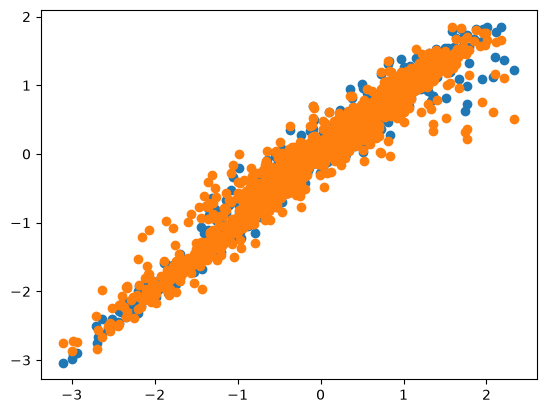

0.031003352381229143
0.05965069614633437


In [24]:
plt.scatter(y_train, v_gp_predictive_mean)
plt.scatter(y_train, jnp.mean(projected, axis=1))
plt.show()

diff1 = (y_train - v_gp_predictive_mean.squeeze())**2
diff2 = (y_train - jnp.mean(projected, axis=1))**2

print(jnp.mean((y_train[:, 0] - v_gp_predictive_mean)**2))
print(jnp.mean((y_train[:, 0] - jnp.mean(projected, axis=1))**2))

In [36]:
pro_params

NonTrainable(tree=0.0)

In [39]:
burn = int(num_steps * 0.9)
thin = 50

pro_params = pro_params._replace(sigma=px.NonTrainable(jnp.array([0.5])))

particles = info[0].position[burn::thin]
test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_test, pro_params, inducing_basis=inducing_basis)

v_gp_latent_dist = v_gp_posterior.predict(x_test, train_data=data)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

print("PRO NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))
print("VGP NLPD:", nlpd_gp(y_test, v_gp_predictive_mean, v_gp_predictive_std))

nlpd_pro_point = nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params, return_per_point=True)
nlpd_gp_point = nlpd_gp(y_test, v_gp_predictive_mean, v_gp_predictive_std, return_per_point=True)

PRO NLPD: 0.010455980809293499
VGP NLPD: -0.019260289011572118


In [31]:
px.unwrap(pro_params.sigma)

Array(0.24637072, dtype=float64)